In [1]:
import os, time, math, random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from tqdm.auto import tqdm
import matplotlib.pyplot as plt

torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)


device: cuda


In [2]:
import torchvision
import torchvision.transforms as T
from torch.utils.data import DataLoader

def get_cifar10_loaders(batch_size=128, num_workers=None):
    if num_workers is None:
        num_workers = 0 if os.name == "nt" else 4

    transform_train = T.Compose([
        T.RandomCrop(32, padding=4),
        T.RandomHorizontalFlip(),
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])
    transform_test = T.Compose([
        T.ToTensor(),
        T.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ])

    trainset = torchvision.datasets.CIFAR10(root="./data", train=True, download=True, transform=transform_train)
    testset  = torchvision.datasets.CIFAR10(root="./data", train=False, download=True, transform=transform_test)

    train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True,
                              num_workers=num_workers, pin_memory=True,
                              persistent_workers=False)
    test_loader  = DataLoader(testset, batch_size=batch_size, shuffle=False,
                              num_workers=num_workers, pin_memory=True,
                              persistent_workers=False)
    return train_loader, test_loader

train_loader, test_loader = get_cifar10_loaders(batch_size=128)
print("steps/epoch:", len(train_loader), "test iters:", len(test_loader))


steps/epoch: 391 test iters: 79


In [3]:
from torchvision.models import resnet18

def make_resnet18_cifar10():
    model = resnet18(num_classes=10)
    # CIFAR-10 常见改法：3x3 stride1 + no maxpool
    model.conv1 = nn.Conv2d(3, 64, kernel_size=3, stride=1, padding=1, bias=False)
    model.maxpool = nn.Identity()
    return model

criterion = nn.CrossEntropyLoss()


In [4]:
@torch.no_grad()
def eval_loss_acc(model, loader, device, criterion, max_batches=None):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    for i, (xb, yb) in enumerate(loader):
        if max_batches is not None and i >= max_batches:
            break
        xb = xb.to(device, non_blocking=True)
        yb = yb.to(device, non_blocking=True)
        logits = model(xb)
        loss = criterion(logits, yb)
        total_loss += float(loss.item()) * xb.size(0)
        pred = logits.argmax(dim=1)
        correct += int((pred == yb).sum().item())
        total += int(xb.size(0))
    return total_loss / max(total,1), 100.0 * correct / max(total,1)


In [5]:
def _global_norm_sq(tensors):
    s = 0.0
    for t in tensors:
        s += float(torch.sum(t*t).item())
    return s

def _global_dot(tensors_a, tensors_b):
    s = 0.0
    for a, b in zip(tensors_a, tensors_b):
        s += float(torch.sum(a*b).item())
    return s

@torch.no_grad()
def compute_naim_stats(v_list, d_list, prev_d_list=None, eps=1e-8):
    """
    定义：
      z := v - d
      r := ||z||/(||d||+eps)
      dd := d - d_prev
      q_abs := ||dd||, q := q_abs/(||d||+eps)
      dd_perp := dd - <dd,d>/||d||^2 * d
      q_perp_abs := ||dd_perp||, q_perp := q_perp_abs/(||d||+eps)
      cos(v,d) := <v,d>/(||v|| ||d|| + eps)
    """
    z_list = [(v - d) for v, d in zip(v_list, d_list)]

    d_norm = math.sqrt(_global_norm_sq(d_list))
    v_norm = math.sqrt(_global_norm_sq(v_list))
    z_norm = math.sqrt(_global_norm_sq(z_list))

    r_rel = z_norm / (d_norm + eps)

    vd = _global_dot(v_list, d_list)
    cos_vd = vd / (v_norm * d_norm + eps)

    q_abs = None
    q_rel = None
    q_perp_abs = None
    q_perp_rel = None

    if prev_d_list is not None:
        dd_list = [(d - pd) for d, pd in zip(d_list, prev_d_list)]
        q_abs = math.sqrt(_global_norm_sq(dd_list))
        q_rel = q_abs / (d_norm + eps)

        dd_dot_d = _global_dot(dd_list, d_list)
        dd_norm_sq = _global_norm_sq(dd_list)
        d_norm_sq  = _global_norm_sq(d_list) + eps
        dd_perp_sq = max(dd_norm_sq - (dd_dot_d*dd_dot_d)/d_norm_sq, 0.0)
        q_perp_abs = math.sqrt(dd_perp_sq)
        q_perp_rel = q_perp_abs / (d_norm + eps)

    return dict(
        d_norm=d_norm, v_norm=v_norm, z_norm=z_norm,
        r_rel=r_rel, cos_vd=cos_vd,
        q_abs=q_abs, q_rel=q_rel,
        q_perp_abs=q_perp_abs, q_perp_rel=q_perp_rel,
    )


In [6]:
from torch.optim import Optimizer

class RLO(Optimizer):
    """
    原始 RLO（一阶）：
      m := exp_avg
      c = beta1*m + (1-beta1)*g
      delta = g - m
      d = sign(c) + belief_coef * delta/(||delta||+eps)
      theta <- theta - lr*d   (decoupled weight decay: theta <- theta*(1-lr*wd))
      m <- beta2*m + (1-beta2)*g
    """
    def __init__(self, params, lr=1e-4, betas=(0.9,0.99), weight_decay=0.1, belief_coef=0.1, eps=1e-8):
        if lr <= 0.0: raise ValueError("lr must be > 0")
        b1, b2 = betas
        if not (0.0 <= b1 < 1.0): raise ValueError("beta1 invalid")
        if not (0.0 <= b2 < 1.0): raise ValueError("beta2 invalid")
        if weight_decay < 0.0: raise ValueError("weight_decay invalid")
        if belief_coef < 0.0: raise ValueError("belief_coef invalid")
        if eps <= 0.0: raise ValueError("eps invalid")
        defaults = dict(lr=lr, betas=betas, weight_decay=weight_decay, belief_coef=belief_coef, eps=eps)
        super().__init__(params, defaults)

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]
            beta1, beta2 = group["betas"]
            wd = group["weight_decay"]
            belief = group["belief_coef"]
            eps = group["eps"]

            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad
                if g.is_sparse:
                    raise RuntimeError("RLO does not support sparse gradients")

                st = self.state[p]
                if len(st) == 0:
                    st["exp_avg"] = torch.zeros_like(p)

                m = st["exp_avg"]

                # decoupled weight decay
                if wd != 0.0:
                    p.mul_(1.0 - lr * wd)

                c = beta1*m + (1.0-beta1)*g
                delta = g - m
                d = torch.sign(c) + belief * (delta / (delta.norm(p=2) + eps))

                p.add_(d, alpha=-lr)

                m.mul_(beta2).add_(g, alpha=(1.0-beta2))

        return loss


In [7]:
class RLO_Logged:
    def __init__(self, rlo_optimizer, log_interval=10, eps=1e-8):
        self.opt = rlo_optimizer
        self.log_interval = int(log_interval)
        self.eps = eps
        self._step = 0
        self._prev_d = None

        self.log = {k: [] for k in [
            "step","d_norm","v_norm","z_norm","r_rel","cos_vd",
            "q_abs","q_rel","q_perp_abs","q_perp_rel"
        ]}

    def zero_grad(self, *args, **kwargs):
        return self.opt.zero_grad(*args, **kwargs)

    @torch.no_grad()
    def _compute_d_list(self):
        d_list = []
        for group in self.opt.param_groups:
            beta1, beta2 = group["betas"]
            belief = group["belief_coef"]
            eps = group["eps"]
            for p in group["params"]:
                if p.grad is None:
                    continue
                st = self.opt.state[p]
                if "exp_avg" not in st:
                    st["exp_avg"] = torch.zeros_like(p)
                m = st["exp_avg"]
                g = p.grad
                c = beta1*m + (1.0-beta1)*g
                delta = g - m
                d = torch.sign(c) + belief * (delta / (delta.norm(p=2) + eps))
                d_list.append(d.detach().clone())
        return d_list

    @torch.no_grad()
    def maybe_log(self):
        if self._step % self.log_interval != 0:
            return
        d_list = self._compute_d_list()
        v_list = [d.clone() for d in d_list]  # 一阶投影解释

        stats = compute_naim_stats(v_list, d_list, prev_d_list=self._prev_d, eps=self.eps)
        # 强制一阶投影的精确不变量
        stats["z_norm"] = 0.0
        stats["r_rel"] = 0.0
        stats["cos_vd"] = 1.0
        stats["v_norm"] = stats["d_norm"]

        self.log["step"].append(self._step)
        for k in ["d_norm","v_norm","z_norm","r_rel","cos_vd","q_abs","q_rel","q_perp_abs","q_perp_rel"]:
            self.log[k].append(stats[k] if stats[k] is not None else np.nan)

        self._prev_d = [d.detach().clone() for d in d_list]

    def step(self, closure=None):
        self.maybe_log()
        out = self.opt.step(closure=closure)
        self._step += 1
        return out

    def get_log(self):
        return self.log


In [8]:
class RLO_LambdaA(Optimizer):
    """
    新 Lambda 的一阶 RLO（无显式 v；用 v:=d 的投影解释）：
      s <- beta3 s + (1-beta3) g^2
      c = beta1*m + (1-beta1)*g
      smooth = tanh(gamma*c)
      smooth_pre = smooth/(sqrt(s)+eps)
      d = scale_to_sqrtD(smooth_pre) + lambda_b * delta/(||delta||+eps)
      theta <- theta - lr*d   (decoupled weight decay)
      m <- beta2*m + (1-beta2)*g
    并记录 NAIM log（使用 v:=d 解释）。
    """
    def __init__(self, params, lr=1e-4, beta1=0.9, beta2=0.99, beta3=0.999,
                 weight_decay=0.1, lambda_b=0.1, eps=1e-8,
                 gamma=5.0, log_interval=10):
        defaults = dict(lr=lr, beta1=beta1, beta2=beta2, beta3=beta3,
                        weight_decay=weight_decay, lambda_b=lambda_b,
                        eps=eps, gamma=gamma, log_interval=int(log_interval))
        super().__init__(params, defaults)

        self._step = 0
        self._prev_d = None
        self.log = {k: [] for k in [
            "step","d_norm","v_norm","z_norm","r_rel","cos_vd",
            "q_abs","q_rel","q_perp_abs","q_perp_rel"
        ]}

        total_dim = 0
        for group in self.param_groups:
            for p in group["params"]:
                total_dim += p.numel()
        self.sqrt_dim = math.sqrt(total_dim)

    @torch.no_grad()
    def _maybe_log(self, d_list, group):
        if self._step % group["log_interval"] != 0:
            return
        v_list = [d.clone() for d in d_list]  # 一阶投影解释
        stats = compute_naim_stats(v_list, d_list, prev_d_list=self._prev_d, eps=group["eps"])
        # 一阶投影强制
        stats["z_norm"] = 0.0
        stats["r_rel"] = 0.0
        stats["cos_vd"] = 1.0
        stats["v_norm"] = stats["d_norm"]

        self.log["step"].append(self._step)
        for k in ["d_norm","v_norm","z_norm","r_rel","cos_vd","q_abs","q_rel","q_perp_abs","q_perp_rel"]:
            self.log[k].append(stats[k] if stats[k] is not None else np.nan)

        self._prev_d = [d.detach().clone() for d in d_list]

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]; eps = group["eps"]
            wd = group["weight_decay"]; gamma = group["gamma"]
            beta1 = group["beta1"]; beta2 = group["beta2"]; beta3 = group["beta3"]
            lambda_b = group["lambda_b"]

            # collect smooth_pre tensors to compute global scale
            smooth_pre_list = []
            belief_list = []
            params_list = []

            # first pass: build components and update second moment s
            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad
                st = self.state[p]
                if len(st) == 0:
                    st["m"] = torch.zeros_like(p)
                    st["s"] = torch.zeros_like(p)

                m = st["m"]
                s = st["s"]

                # second moment
                s.mul_(beta3).addcmul_(g, g, value=(1.0-beta3))

                c = beta1*m + (1.0-beta1)*g
                smooth = torch.tanh(gamma * c)
                smooth_pre = smooth / (torch.sqrt(s) + eps)

                delta = g - m
                belief = lambda_b * (delta / (delta.norm(p=2) + eps))

                smooth_pre_list.append(smooth_pre)
                belief_list.append(belief)
                params_list.append(p)

            if len(params_list) == 0:
                self._step += 1
                return loss

            S_norm = math.sqrt(_global_norm_sq(smooth_pre_list))
            scale = self.sqrt_dim / (S_norm + eps)

            d_list = [scale*sp + b for sp, b in zip(smooth_pre_list, belief_list)]

            # log pre-update
            self._maybe_log(d_list, group)

            # apply update
            for p, d in zip(params_list, d_list):
                g = p.grad
                st = self.state[p]
                m = st["m"]

                if wd != 0.0:
                    p.mul_(1.0 - lr*wd)

                p.add_(d, alpha=-lr)

                m.mul_(beta2).add_(g, alpha=(1.0-beta2))

        self._step += 1
        return loss

    def get_log(self):
        return self.log


In [9]:
class SmoothLiftedRLO(Optimizer):
    """
    二阶 lifted：
      c = beta1*m + (1-beta1)*g
      s = tanh(gamma*c)
      s_scaled = sqrt(D) * s / (||s|| + eps)        (全局幅值校准)
      delta = g - m
      d = s_scaled + lambda_b * delta/(||delta||+eps)

      v <- (1-eta) v + eta d
      theta <- theta - lr*v     (decoupled weight decay)
      m <- beta2*m + (1-beta2)*g

    NAIM log 用真实 v,d，因此 z=v-d 可测。
    """
    def __init__(self, params, lr=1e-4, beta1=0.9, beta2=0.99, eta=0.3,
                 weight_decay=0.1, lambda_b=0.1, eps=1e-8, gamma=5.0,
                 log_interval=10):
        defaults = dict(lr=lr, beta1=beta1, beta2=beta2, eta=eta,
                        weight_decay=weight_decay, lambda_b=lambda_b,
                        eps=eps, gamma=gamma, log_interval=int(log_interval))
        super().__init__(params, defaults)

        self._step = 0
        self._prev_d = None
        self.log = {k: [] for k in [
            "step","d_norm","v_norm","z_norm","r_rel","cos_vd",
            "q_abs","q_rel","q_perp_abs","q_perp_rel"
        ]}

        total_dim = 0
        for group in self.param_groups:
            for p in group["params"]:
                total_dim += p.numel()
        self.sqrt_dim = math.sqrt(total_dim)

    @torch.no_grad()
    def _maybe_log(self, v_list, d_list, group):
        if self._step % group["log_interval"] != 0:
            return
        stats = compute_naim_stats(v_list, d_list, prev_d_list=self._prev_d, eps=group["eps"])
        self.log["step"].append(self._step)
        for k in ["d_norm","v_norm","z_norm","r_rel","cos_vd","q_abs","q_rel","q_perp_abs","q_perp_rel"]:
            self.log[k].append(stats[k] if stats[k] is not None else np.nan)
        self._prev_d = [d.detach().clone() for d in d_list]

    @torch.no_grad()
    def step(self, closure=None):
        loss = None
        if closure is not None:
            with torch.enable_grad():
                loss = closure()

        for group in self.param_groups:
            lr = group["lr"]; eps = group["eps"]
            wd = group["weight_decay"]; gamma = group["gamma"]
            beta1 = group["beta1"]; beta2 = group["beta2"]; eta = group["eta"]
            lambda_b = group["lambda_b"]

            # pass 1: build smooth tensors s and belief, gather v tensors, ensure state init
            S_list = []
            B_list = []
            V_list = []
            params_list = []
            for p in group["params"]:
                if p.grad is None:
                    continue
                g = p.grad
                st = self.state[p]
                if len(st) == 0:
                    st["m"] = torch.zeros_like(p)
                    st["v"] = torch.zeros_like(p)
                m = st["m"]; v = st["v"]

                c = beta1*m + (1.0-beta1)*g
                s = torch.tanh(gamma*c)

                delta = g - m
                b = lambda_b * (delta / (delta.norm(p=2) + eps))

                S_list.append(s)
                B_list.append(b)
                V_list.append(v)   # pre-update v
                params_list.append(p)

            if len(params_list) == 0:
                self._step += 1
                return loss

            S_norm = math.sqrt(_global_norm_sq(S_list))
            scale = self.sqrt_dim / (S_norm + eps)

            d_list = [scale*s + b for s, b in zip(S_list, B_list)]

            # log pre-update (真实 v,d)
            self._maybe_log(V_list, d_list, group)

            # apply updates
            for p, d in zip(params_list, d_list):
                g = p.grad
                st = self.state[p]
                m = st["m"]; v = st["v"]

                if wd != 0.0:
                    p.mul_(1.0 - lr*wd)

                v.mul_(1.0-eta).add_(d, alpha=eta)
                p.add_(v, alpha=-lr)
                m.mul_(beta2).add_(g, alpha=(1.0-beta2))

        self._step += 1
        return loss

    def get_log(self):
        return self.log


In [10]:
def train_one(model_fn, optimizer_name, make_optimizer_fn,
              train_loader, test_loader, device, criterion,
              num_epochs=50, train_eval_batches=50):
    model = model_fn().to(device)
    opt = make_optimizer_fn(model.parameters())

    history = {"train_loss": [], "train_acc": [], "test_loss": [], "test_acc": []}
    best_acc = -1.0
    t0 = time.time()

    for epoch in range(1, num_epochs+1):
        model.train()
        running = 0.0
        nstep = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch:03d}/{num_epochs} [{optimizer_name}]", leave=False)
        for xb, yb in pbar:
            xb = xb.to(device, non_blocking=True)
            yb = yb.to(device, non_blocking=True)

            if hasattr(opt, "zero_grad"):
                opt.zero_grad(set_to_none=True)

            logits = model(xb)
            loss = criterion(logits, yb)
            loss.backward()

            opt.step()

            running += float(loss.item())
            nstep += 1
            pbar.set_postfix(loss=f"{running/max(nstep,1):.4f}")

        trL, trA = eval_loss_acc(model, train_loader, device, criterion, max_batches=train_eval_batches)
        teL, teA = eval_loss_acc(model, test_loader, device, criterion, max_batches=None)

        history["train_loss"].append(trL)
        history["train_acc"].append(trA)
        history["test_loss"].append(teL)
        history["test_acc"].append(teA)

        best_acc = max(best_acc, teA)
        print(f"[{optimizer_name:18s}] epoch={epoch:03d}  train_acc={trA:6.2f}%  test_acc={teA:6.2f}%  test_loss={teL:.4f}")

    time_per_epoch = (time.time() - t0) / num_epochs

    naim_log = None
    if hasattr(opt, "get_log"):
        naim_log = opt.get_log()
    elif hasattr(opt, "log"):
        naim_log = opt.log

    return dict(
        name=optimizer_name,
        model=model,
        optimizer=opt,
        history=history,
        best_acc=float(best_acc),
        final_acc=float(history["test_acc"][-1]),
        time_per_epoch=float(time_per_epoch),
        naim_log=naim_log,
        steps_per_epoch=len(train_loader),
    )


In [11]:
NUM_EPOCHS = 50
LOG_INTERVAL = 10

# Optimizer configs
def make_adamw(params):
    return torch.optim.AdamW(params, lr=1e-3, betas=(0.9,0.999), eps=1e-8, weight_decay=0.05)

def make_rlo_logged(params):
    base = RLO(params, lr=1e-4, betas=(0.9,0.99), weight_decay=0.1, belief_coef=0.1, eps=1e-8)
    return RLO_Logged(base, log_interval=LOG_INTERVAL)

def make_rlo_lambdaA(params):
    return RLO_LambdaA(params, lr=1e-4, beta1=0.9, beta2=0.99, beta3=0.999,
                       weight_decay=0.1, lambda_b=0.1, eps=1e-8, gamma=5.0,
                       log_interval=LOG_INTERVAL)

def make_smoothlifted(params, eta):
    return SmoothLiftedRLO(params, lr=1e-4, beta1=0.9, beta2=0.99, eta=eta,
                           weight_decay=0.1, lambda_b=0.1, eps=1e-8, gamma=5.0,
                           log_interval=LOG_INTERVAL)

results = {}

# AdamW
results["AdamW"] = train_one(make_resnet18_cifar10, "AdamW", make_adamw,
                             train_loader, test_loader, device, criterion,
                             num_epochs=NUM_EPOCHS)

# RLO logged
results["RLO"] = train_one(make_resnet18_cifar10, "RLO (logged)", make_rlo_logged,
                           train_loader, test_loader, device, criterion,
                           num_epochs=NUM_EPOCHS)

# New-Lambda RLO
results["RLO_LambdaA"] = train_one(make_resnet18_cifar10, "RLO_LambdaA", make_rlo_lambdaA,
                                   train_loader, test_loader, device, criterion,
                                   num_epochs=NUM_EPOCHS)

# SmoothLifted sweep
etas = [0.7, 0.5, 0.3, 0.2, 0.1]
for eta in etas:
    key = f"SmoothLifted_eta{eta}"
    results[key] = train_one(make_resnet18_cifar10, f"SmoothLifted(eta={eta})",
                             lambda params, eta=eta: make_smoothlifted(params, eta),
                             train_loader, test_loader, device, criterion,
                             num_epochs=NUM_EPOCHS)


Epoch 001/50 [AdamW]:   0%|          | 0/391 [00:00<?, ?it/s]

[AdamW             ] epoch=001  train_acc= 57.86%  test_acc= 58.97%  test_loss=1.1754


Epoch 002/50 [AdamW]:   0%|          | 0/391 [00:00<?, ?it/s]

[AdamW             ] epoch=002  train_acc= 71.67%  test_acc= 72.41%  test_loss=0.7950


Epoch 003/50 [AdamW]:   0%|          | 0/391 [00:00<?, ?it/s]

...

[SmoothLifted(eta=0.1)] epoch=048  train_acc= 97.80%  test_acc= 90.40%  test_loss=0.4287


Epoch 049/50 [SmoothLifted(eta=0.1)]:   0%|          | 0/391 [00:00<?, ?it/s]

[SmoothLifted(eta=0.1)] epoch=049  train_acc= 98.17%  test_acc= 90.72%  test_loss=0.4335


Epoch 050/50 [SmoothLifted(eta=0.1)]:   0%|          | 0/391 [00:00<?, ?it/s]

[SmoothLifted(eta=0.1)] epoch=050  train_acc= 97.61%  test_acc= 90.22%  test_loss=0.4462


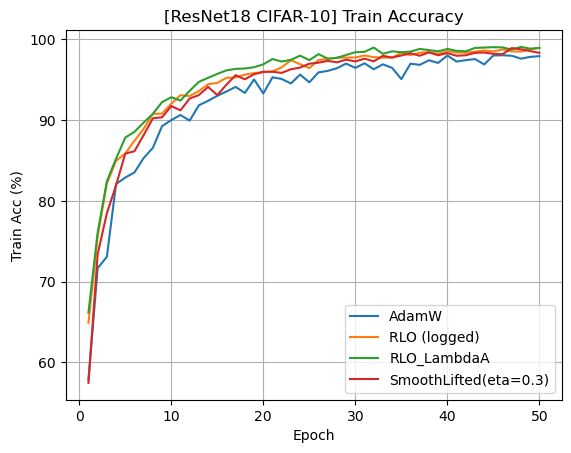

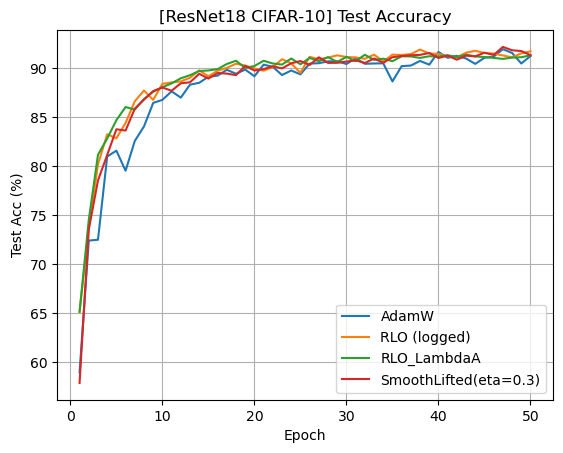

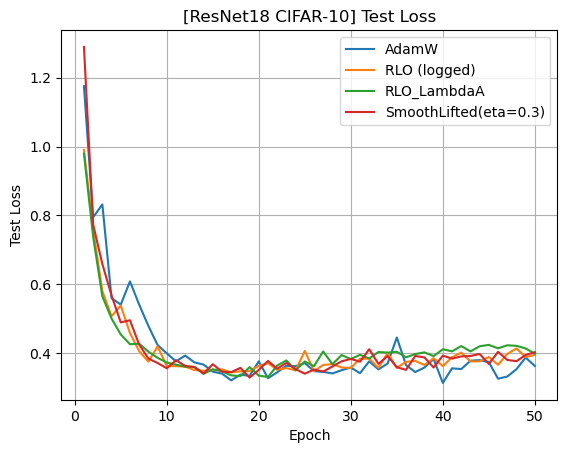

In [12]:
def plot_curves(results, keys, title=""):
    # Train acc
    plt.figure()
    for k in keys:
        h = results[k]["history"]
        plt.plot(np.arange(1, len(h["train_acc"])+1), h["train_acc"], label=results[k]["name"])
    plt.xlabel("Epoch"); plt.ylabel("Train Acc (%)"); plt.grid(True)
    plt.title(title + " Train Accuracy"); plt.legend(); plt.show()

    # Test acc
    plt.figure()
    for k in keys:
        h = results[k]["history"]
        plt.plot(np.arange(1, len(h["test_acc"])+1), h["test_acc"], label=results[k]["name"])
    plt.xlabel("Epoch"); plt.ylabel("Test Acc (%)"); plt.grid(True)
    plt.title(title + " Test Accuracy"); plt.legend(); plt.show()

    # Test loss
    plt.figure()
    for k in keys:
        h = results[k]["history"]
        plt.plot(np.arange(1, len(h["test_loss"])+1), h["test_loss"], label=results[k]["name"])
    plt.xlabel("Epoch"); plt.ylabel("Test Loss"); plt.grid(True)
    plt.title(title + " Test Loss"); plt.legend(); plt.show()

base_keys = ["AdamW", "RLO", "RLO_LambdaA", "SmoothLifted_eta0.3"]
plot_curves(results, base_keys, title="[ResNet18 CIFAR-10]")


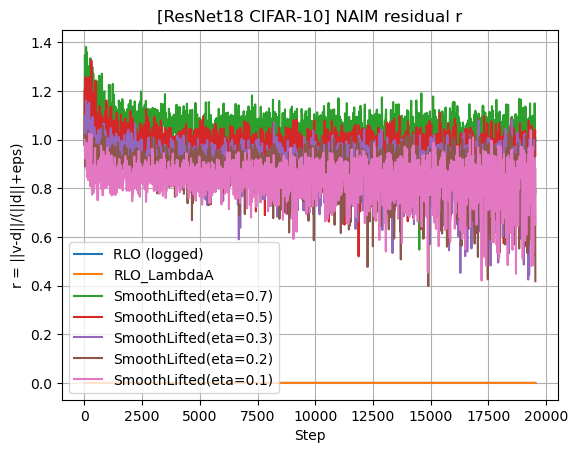

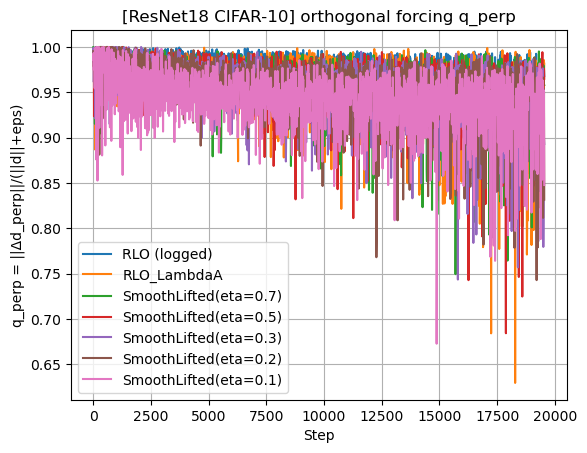

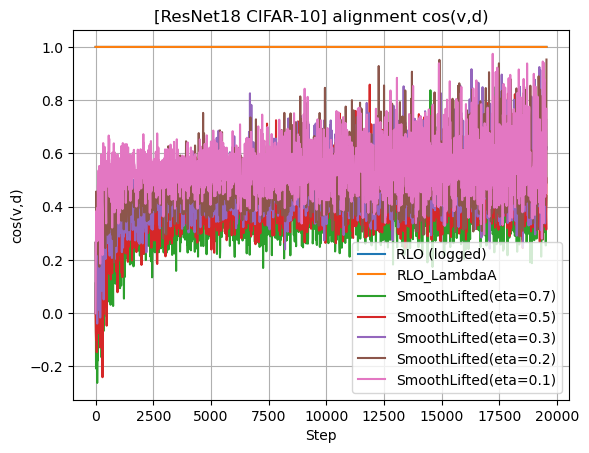

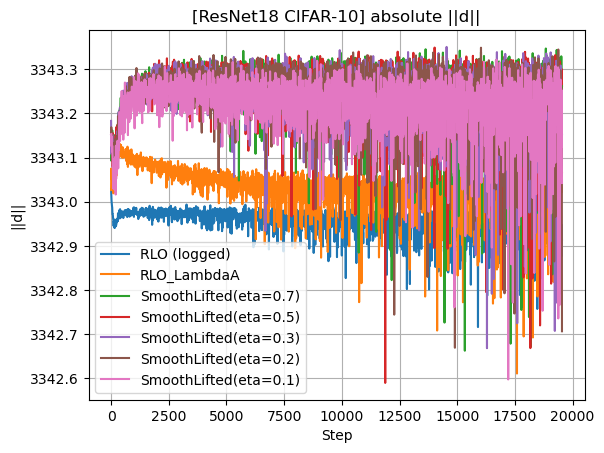

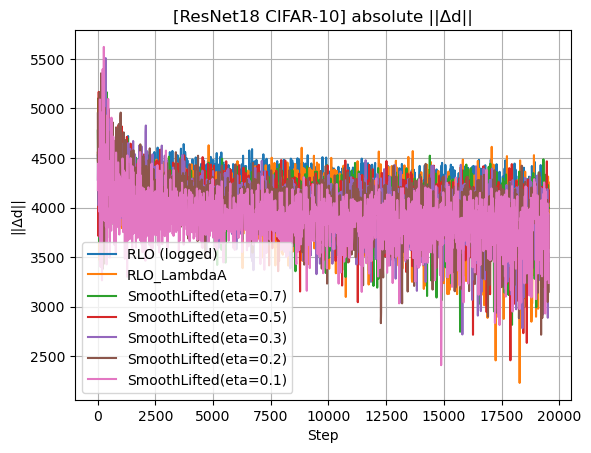

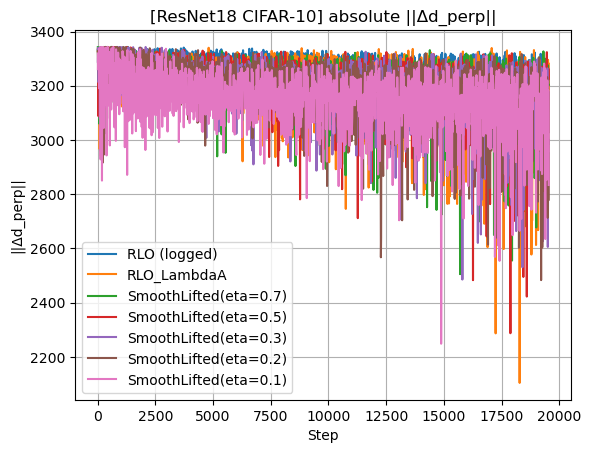

In [13]:
def plot_naim(results, keys, title=""):
    def _get(log, name):
        arr = np.array(log[name], dtype=float)
        return arr

    # r
    plt.figure()
    for k in keys:
        log = results[k]["naim_log"]
        if log is None: 
            continue
        plt.plot(log["step"], _get(log,"r_rel"), label=results[k]["name"])
    plt.xlabel("Step"); plt.ylabel("r = ||v-d||/(||d||+eps)"); plt.grid(True)
    plt.title(title + " NAIM residual r"); plt.legend(); plt.show()

    # q_perp_rel
    plt.figure()
    for k in keys:
        log = results[k]["naim_log"]
        if log is None: 
            continue
        plt.plot(log["step"], _get(log,"q_perp_rel"), label=results[k]["name"])
    plt.xlabel("Step"); plt.ylabel("q_perp = ||Δd_perp||/(||d||+eps)"); plt.grid(True)
    plt.title(title + " orthogonal forcing q_perp"); plt.legend(); plt.show()

    # cos(v,d)
    plt.figure()
    for k in keys:
        log = results[k]["naim_log"]
        if log is None: 
            continue
        plt.plot(log["step"], _get(log,"cos_vd"), label=results[k]["name"])
    plt.xlabel("Step"); plt.ylabel("cos(v,d)"); plt.grid(True)
    plt.title(title + " alignment cos(v,d)"); plt.legend(); plt.show()

    # absolute ||d||
    plt.figure()
    for k in keys:
        log = results[k]["naim_log"]
        if log is None: 
            continue
        plt.plot(log["step"], _get(log,"d_norm"), label=results[k]["name"])
    plt.xlabel("Step"); plt.ylabel("||d||"); plt.grid(True)
    plt.title(title + " absolute ||d||"); plt.legend(); plt.show()

    # absolute ||Δd|| and ||Δd_perp||
    plt.figure()
    for k in keys:
        log = results[k]["naim_log"]
        if log is None: 
            continue
        plt.plot(log["step"], _get(log,"q_abs"), label=results[k]["name"])
    plt.xlabel("Step"); plt.ylabel("||Δd||"); plt.grid(True)
    plt.title(title + " absolute ||Δd||"); plt.legend(); plt.show()

    plt.figure()
    for k in keys:
        log = results[k]["naim_log"]
        if log is None: 
            continue
        plt.plot(log["step"], _get(log,"q_perp_abs"), label=results[k]["name"])
    plt.xlabel("Step"); plt.ylabel("||Δd_perp||"); plt.grid(True)
    plt.title(title + " absolute ||Δd_perp||"); plt.legend(); plt.show()

naim_keys = ["RLO", "RLO_LambdaA"] + [f"SmoothLifted_eta{e}" for e in [0.7,0.5,0.3,0.2,0.1]]
plot_naim(results, naim_keys, title="[ResNet18 CIFAR-10]")


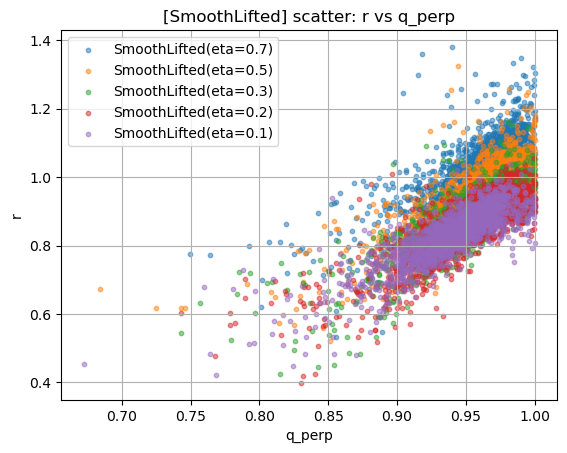

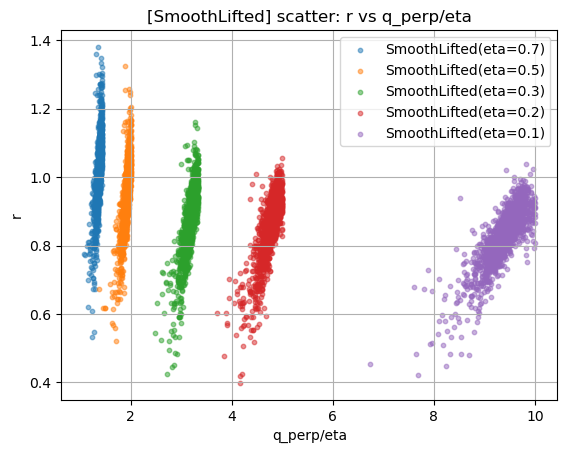

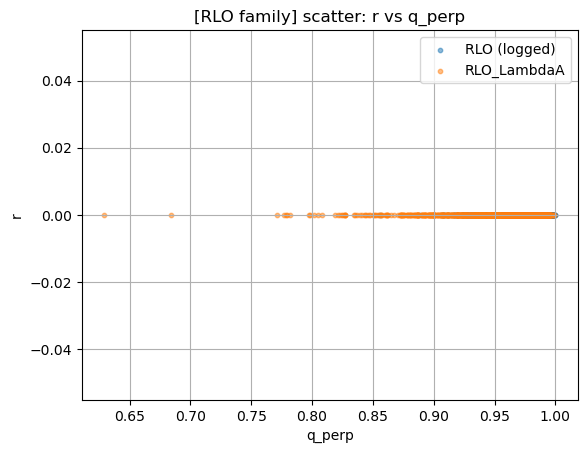

In [14]:
def scatter_r_vs_qperp(results, keys, title="", divide_by_eta=False):
    plt.figure()
    for k in keys:
        log = results[k]["naim_log"]
        if log is None:
            continue
        r = np.array(log["r_rel"], dtype=float)
        qp = np.array(log["q_perp_rel"], dtype=float)

        # 对 lifted：如果 divide_by_eta=True，则画 qp/eta
        if divide_by_eta and ("SmoothLifted" in k):
            # 从 name 里解析 eta（也可直接在 key 里解析）
            eta = float(k.split("eta")[-1])
            qp = qp / max(eta, 1e-12)

        mask = np.isfinite(r) & np.isfinite(qp)
        plt.scatter(qp[mask], r[mask], s=10, alpha=0.5, label=results[k]["name"])

    plt.xlabel("q_perp" + ("/eta" if divide_by_eta else ""))
    plt.ylabel("r")
    plt.grid(True)
    plt.title(title + " scatter: r vs q_perp" + ("/eta" if divide_by_eta else ""))
    plt.legend()
    plt.show()

scatter_r_vs_qperp(results, [k for k in naim_keys if "SmoothLifted" in k], title="[SmoothLifted]", divide_by_eta=False)
scatter_r_vs_qperp(results, [k for k in naim_keys if "SmoothLifted" in k], title="[SmoothLifted]", divide_by_eta=True)

# RLO / RLO_LambdaA（一阶投影，r=0；主要看 q_perp 分布）
scatter_r_vs_qperp(results, ["RLO", "RLO_LambdaA"], title="[RLO family]", divide_by_eta=False)


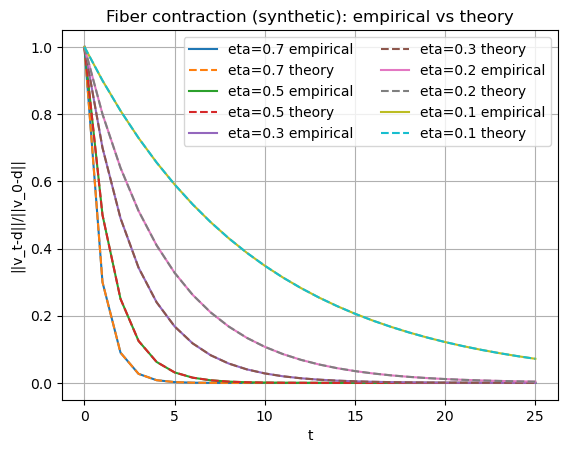

In [15]:
def fiber_contraction_synthetic(etas=(0.7,0.5,0.3,0.2,0.1), T=25, dim=200000, trials=5, seed=0):
    rng = np.random.RandomState(seed)
    d = rng.randn(dim).astype(np.float32)
    d_norm = np.linalg.norm(d) + 1e-12

    plt.figure()
    for eta in etas:
        curves = []
        for _ in range(trials):
            v0 = d + 0.5*rng.randn(dim).astype(np.float32)  # perturb
            e0 = v0 - d
            e0n = np.linalg.norm(e0) + 1e-12
            vals = []
            v = v0.copy()
            for t in range(T+1):
                et = v - d
                vals.append(np.linalg.norm(et)/e0n)
                v = (1.0-eta)*v + eta*d
            curves.append(vals)
        emp = np.mean(np.array(curves), axis=0)
        th = np.array([(1.0-eta)**t for t in range(T+1)], dtype=np.float32)
        plt.plot(np.arange(T+1), emp, label=f"eta={eta} empirical")
        plt.plot(np.arange(T+1), th, linestyle="--", label=f"eta={eta} theory")
    plt.xlabel("t"); plt.ylabel("||v_t-d||/||v_0-d||"); plt.grid(True)
    plt.title("Fiber contraction (synthetic): empirical vs theory")
    plt.legend(ncol=2)
    plt.show()

fiber_contraction_synthetic()


In [16]:
import json, numpy as np

# 1) 选你要导出的实验 key（按你 notebook 的 results 结构）
keys = [
    "AdamW",
    "RLO",
    "RLO_LambdaA",
    # SmoothLifted 的 key 名在你 notebook 里类似 "SmoothLifted_eta0.7" 这种
    "SmoothLifted_eta0.7",
    "SmoothLifted_eta0.5",
    "SmoothLifted_eta0.3",
    "SmoothLifted_eta0.2",
    "SmoothLifted_eta0.1",
]

# 2) 从 results 里抽取并做一个“可序列化”的 dict
export = {}
for k in keys:
    item = results[k]
    log = item.get("naim_log", None)

    export[k] = {
        "name": item.get("name", k),
        "best_test_acc": item.get("best_test_acc", None),
        "final_test_acc": item.get("test_acc", [None])[-1] if "test_acc" in item else None,
        "naim_log": None if log is None else {kk: list(map(float, log[kk])) for kk in log.keys()},
    }

# 3) 打印一个“贴到聊天里刚好够用”的摘要（不刷屏）
def summarize_log(log):
    if log is None:
        return None
    r = np.array(log["r_rel"], dtype=float)
    qp = np.array(log["q_perp_rel"], dtype=float)
    c = np.array(log["cos_vd"], dtype=float)
    # 只看有限值
    m = np.isfinite(r) & np.isfinite(qp) & np.isfinite(c)
    if m.sum() == 0:
        return None
    return {
        "r_rel_mean": float(r[m].mean()),
        "r_rel_last": float(r[m][-1]),
        "q_perp_rel_mean": float(qp[m].mean()),
        "cos_vd_mean": float(c[m].mean()),
    }

for k in keys:
    log = export[k]["naim_log"]
    print("====", k, "====")
    print("name:", export[k]["name"])
    print("best_test_acc:", export[k]["best_test_acc"], " final_test_acc:", export[k]["final_test_acc"])
    print("naim_summary:", summarize_log(log))

# 4) 保存到文件（两种任选其一）
# 4.1 保存 JSON（可读性强，文件可能稍大）
with open("naim_export.json", "w") as f:
    json.dump(export, f, indent=2)

# 4.2 保存 NPZ（紧凑）
npz_dict = {}
for k in keys:
    log = export[k]["naim_log"]
    if log is None:
        continue
    for kk, vv in log.items():
        npz_dict[f"{k}__{kk}"] = np.asarray(vv, dtype=np.float32)
np.savez("naim_export.npz", **npz_dict)

print("Saved: naim_export.json and naim_export.npz")


==== AdamW ====
name: AdamW
best_test_acc: None  final_test_acc: None
naim_summary: None
==== RLO ====
name: RLO (logged)
best_test_acc: None  final_test_acc: None
naim_summary: {'r_rel_mean': 0.0, 'r_rel_last': 0.0, 'q_perp_rel_mean': 0.9772378631590866, 'cos_vd_mean': 1.0}
==== RLO_LambdaA ====
name: RLO_LambdaA
best_test_acc: None  final_test_acc: None
naim_summary: {'r_rel_mean': 0.0, 'r_rel_last': 0.0, 'q_perp_rel_mean': 0.9565016243428806, 'cos_vd_mean': 1.0}
==== SmoothLifted_eta0.7 ====
name: SmoothLifted(eta=0.7)
best_test_acc: None  final_test_acc: None
naim_summary: {'r_rel_mean': 1.0330618861296272, 'r_rel_last': 0.9931337101870791, 'q_perp_rel_mean': 0.9595599828306184, 'cos_vd_mean': 0.36439701641984745}
==== SmoothLifted_eta0.5 ====
name: SmoothLifted(eta=0.5)
best_test_acc: None  final_test_acc: None
naim_summary: {'r_rel_mean': 0.9581977982976546, 'r_rel_last': 0.9343105665227104, 'q_perp_rel_mean': 0.9584701415147406, 'cos_vd_mean': 0.4149203476836301}
==== SmoothLift